In [5]:
!git clone https://github.com/denisevaldivia/Disney_GAN.git
import os
os.chdir('Disney_GAN')

Cloning into 'Disney_GAN'...
remote: Enumerating objects: 158, done.
remote: Counting objects: 100% (4/4), done.
remote: Compressing objects: 100% (4/4), done.
remote: Total 158 (delta 0), reused 0 (delta 0), pack-reused 154 (from 1)
Receiving objects: 100% (158/158), 232.13 MiB | 46.07 MiB/s, done.
Resolving deltas: 100% (57/57), done.
Updating files: 100% (37/37), done.


In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
# Install dependencies for metrics
!pip install scikit-image pytorch-fid

import sys
import os
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

sys.path.append('/content/Disney_GAN')
from src.models.CUT_Generator import define_G_inference

print(f"CUDA available: {torch.cuda.is_available()}")

CUDA available: True


In [8]:
import zipfile

# Paths
weights_path = "/content/drive/MyDrive/Diego/Disney_GAN/CUT_checkpoints/disney_FastCUT/latest_net_G.pth"
dataset_zip = "/content/drive/MyDrive/Diego/Disney_GAN/dataset_GAN_faces.zip"
extract_to = "/content/temp_test_dataset"

# Extract test images from zip
os.makedirs(extract_to, exist_ok=True)
with zipfile.ZipFile(dataset_zip, 'r') as zip_ref:
    zip_ref.extractall(extract_to)

photos_folder = os.path.join(extract_to, "test", "live_action")
print("images extractedto:", photos_folder)


# Model configuration(same as training)
INPUT_NC = 3
OUTPUT_NC = 3
NGF = 64
NET_G = "resnet_9blocks"
NORM = "instance"
NO_ANTIALIAS = False
NO_ANTIALIAS_UP = False

CROP_SIZE = 256
NUM_IMAGES = 15
GRID_ROWS = 3
GRID_COLS = 5

images extractedto: /content/temp_test_dataset/test/live_action


In [9]:
# Load generator
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

gen = define_G_inference(
    input_nc=INPUT_NC,
    output_nc=OUTPUT_NC,
    ngf=NGF,
    netG=NET_G,
    weights_path=weights_path,
    norm=NORM,
    use_dropout=False,
    no_antialias=NO_ANTIALIAS,
    no_antialias_up=NO_ANTIALIAS_UP
)

gen.to(device)
gen.eval()

print("Generator loaded")

Using device: cuda
Loading CUT generator weights from /content/drive/MyDrive/Diego/Disney_GAN/CUT_checkpoints/disney_FastCUT/latest_net_G.pth
Weights loaded successfully
Generator loaded


In [10]:
def preprocess_image(path, size=(256, 256)):
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, size)

    # Convert to tensor and normalize
    tensor = torch.from_numpy(img).float().permute(2, 0, 1).unsqueeze(0)
    tensor = (tensor / 255.0) * 2.0 - 1.0  # [0, 255] -> [0, 1] -> [-1, 1]

    return tensor


def postprocess_image(tensor):
    img = tensor.squeeze(0).permute(1, 2, 0).cpu().detach().numpy()
    img = ((img + 1.0) / 2.0) * 255.0  # [-1, 1] -> [0, 1] -> [0, 255]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

In [14]:
# Get images with full paths
image_filenames = [f for f in os.listdir(photos_folder) if f.lower().endswith(('.jpg'))]
image_paths = [os.path.join(photos_folder, f) for f in image_filenames]
print(f"Found {len(image_paths)} images in {photos_folder}")

Found 53 images in /content/temp_test_dataset/test/live_action


In [15]:
# inference

results = []
num_to_process = min(NUM_IMAGES, len(image_paths))

with torch.no_grad():
    for i, path in enumerate(image_paths[:num_to_process]):
        # Preprocess
        input_tensor = preprocess_image(path, size=(CROP_SIZE, CROP_SIZE))
        input_tensor = input_tensor.to(device)

        # Generation
        output_tensor = gen(input_tensor)

        # Postprocess
        output_img = postprocess_image(output_tensor)

        results.append(output_img)

print(f"\nInference complete")


Inference complete


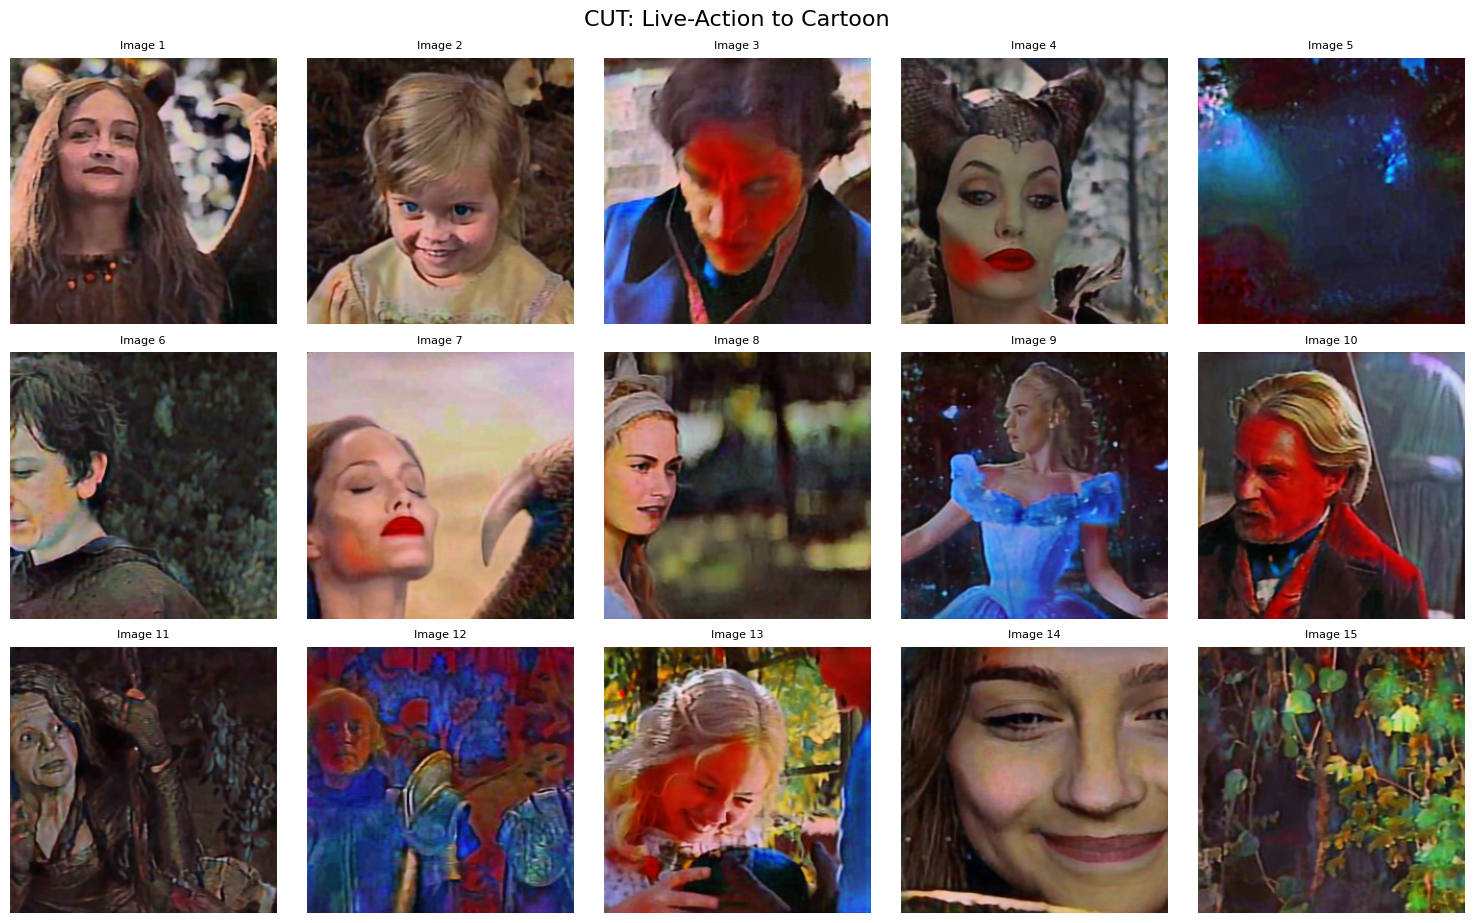

In [16]:
# Results
fig, axes = plt.subplots(GRID_ROWS, GRID_COLS, figsize=(15, 9))
axes = axes.flatten()

for i, ax in enumerate(axes):
    if i < len(results):
        ax.imshow(results[i])
        ax.axis('off')
        ax.set_title(f"Image {i+1}", fontsize=8)
    else:
        ax.axis('off')

plt.tight_layout()
plt.suptitle("CUT: Live-Action to Cartoon", fontsize=16, y=1.02)
plt.show()


In [21]:

def calculate_ssim(img1, img2):
    return ssim(img1, img2, channel_axis=2, data_range=255)

def calculate_psnr(img1, img2):
    return psnr(img1, img2, data_range=255)

def calculate_metrics(real_images, generated_images):
    #getting averages
    ssim_scores = []
    psnr_scores = []

    for real, gen in zip(real_images, generated_images):
        ssim_scores.append(calculate_ssim(real, gen))
        psnr_scores.append(calculate_psnr(real, gen))

    return {
        'ssim_mean': np.mean(ssim_scores),
        'ssim_std': np.std(ssim_scores),
        'psnr_mean': np.mean(psnr_scores),
        'psnr_std': np.std(psnr_scores),
        'ssim_scores': ssim_scores,
        'psnr_scores': psnr_scores
    }



real_images = []
for path in image_paths[:num_to_process]:
    img = cv2.imread(path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (CROP_SIZE, CROP_SIZE))
    real_images.append(img)

# Calculate metrics
metrics = calculate_metrics(real_images, results)

print(f"ssim_mean: {metrics.get("ssim_mean")}")
print(f"psnr_mean: {metrics.get("ssim_mean")}")


ssim_mean: 0.7135726604002436
psnr_mean: 0.7135726604002436
